# Resume Data EDA

This notebook profiles the dataset used by the training pipeline and checks whether `job_position_name` is a viable prediction target.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.preprocess import TARGET_COLUMN, TEXT_SOURCE_COLUMNS, assemble_resume_text, normalize_columns

DATA_PATH = PROJECT_ROOT / 'data' / 'resume_data.csv'
df = normalize_columns(pd.read_csv(DATA_PATH))
df.head(3)

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667


In [2]:
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print('Column names:')
for column in df.columns:
    print('-', column)

Rows: 9,544
Columns: 35
Column names:
- address
- career_objective
- skills
- educational_institution_name
- degree_names
- passing_years
- educational_results
- result_types
- major_field_of_studies
- professional_company_names
- company_urls
- start_dates
- end_dates
- related_skils_in_job
- positions
- locations
- responsibilities
- extra_curricular_activity_types
- extra_curricular_organization_names
- extra_curricular_organization_links
- role_positions
- languages
- proficiency_levels
- certification_providers
- certification_skills
- online_links
- issue_dates
- expiry_dates
- job_position_name
- educationaL_requirements
- experiencere_requirement
- age_requirement
- responsibilities.1
- skills_required
- matched_score


In [3]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
}).sort_values(['missing_pct', 'missing_count'], ascending=False)

duplicate_rows = int(df.duplicated().sum())
print(f'Duplicate rows: {duplicate_rows:,}')
missing_summary.head(15)

Duplicate rows: 0


,missing_count,missing_pct
languages,8844,92.67
proficiency_levels,8844,92.67
address,8760,91.79
certification_providers,7536,78.96
certification_skills,7536,78.96
online_links,7536,78.96
issue_dates,7536,78.96
expiry_dates,7536,78.96
extra_curricular_activity_types,6118,64.10
extra_curricular_organization_names,6118,64.10


In [4]:
availability = []
for column in TEXT_SOURCE_COLUMNS:
    series = df[column].fillna('').astype(str).str.strip()
    non_empty = (series != '').sum()
    availability.append({
        'column': column,
        'non_empty_rows': int(non_empty),
        'coverage_pct': round(non_empty / len(df) * 100, 2),
    })

availability_df = pd.DataFrame(availability).sort_values('coverage_pct', ascending=False)
availability_df

,column,non_empty_rows,coverage_pct
4,responsibilities,9544,100.00
1,skills,9488,99.41
2,major_field_of_studies,9460,99.12
3,positions,9460,99.12
0,career_objective,4740,49.66


In [5]:
model_df = df.copy()
model_df[TARGET_COLUMN] = model_df[TARGET_COLUMN].fillna('').astype(str).str.strip()
model_df['assembled_text'] = assemble_resume_text(model_df, TEXT_SOURCE_COLUMNS)
model_df = model_df[(model_df[TARGET_COLUMN] != '') & (model_df['assembled_text'] != '')].copy()

model_df['text_word_count'] = model_df['assembled_text'].str.split().str.len()
model_df['text_char_count'] = model_df['assembled_text'].str.len()

print(f'Model-ready rows: {len(model_df):,}')
print(f'Unique target classes: {model_df[TARGET_COLUMN].nunique():,}')
model_df[[TARGET_COLUMN, 'assembled_text', 'text_word_count']].head(3)

Model-ready rows: 9,544
Unique target classes: 28


,job_position_name,assembled_text,text_word_count
0,Senior Software Engineer,big data analytics working and database wareho...,88
1,Machine Learning (ML) Engineer,fresher looking to join as a data analyst and ...,88
2,"Executive/ Senior Executive- Trade Marketing, ...",software development machine learning deep lea...,44


In [6]:
target_counts = model_df[TARGET_COLUMN].value_counts()
print('Top target classes:')
display(target_counts.head(15).to_frame('count'))
print(f'Classes with fewer than 2 rows: {(target_counts < 2).sum()}')
print(f'Classes with fewer than 5 rows: {(target_counts < 5).sum()}')

Top target classes:


,count
job_position_name,
Project Coordinator (Civil),342
Site Engineer,342
Civil Engineer,342
HR Officer,342
Database Administrator (DBA),341
AI Engineer,341
Mechanical Designer,341
Mechanical Engineer,341
"System Administrator (Operation & Maintenance of Server, Storage & Service Desk System)",341


Classes with fewer than 2 rows: 0
Classes with fewer than 5 rows: 0


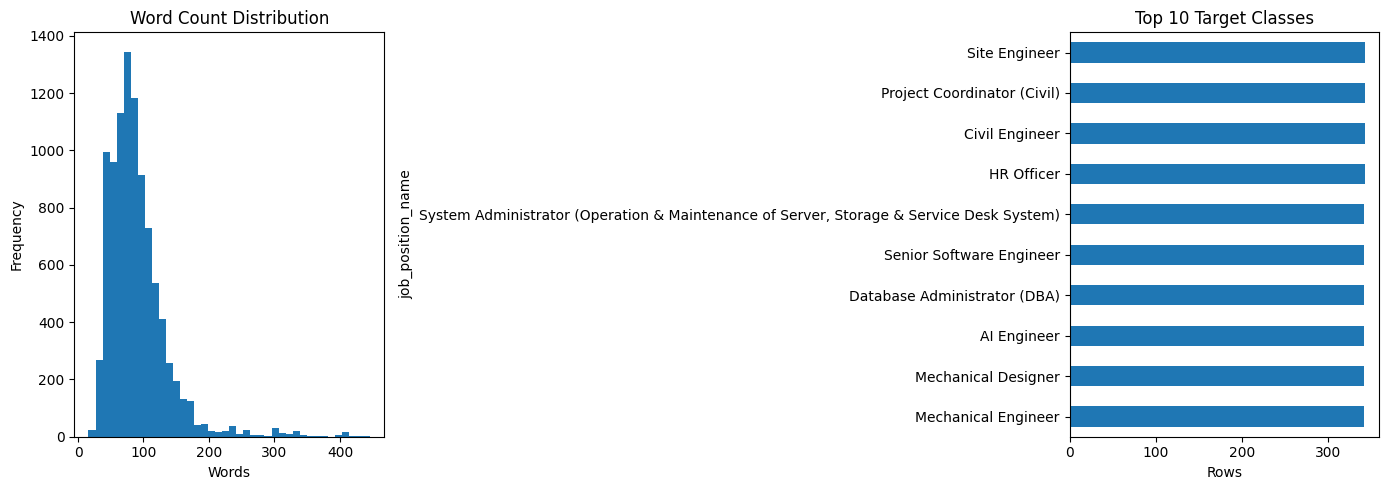

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_df['text_word_count'].plot(kind='hist', bins=40, ax=axes[0], title='Word Count Distribution')
axes[0].set_xlabel('Words')
target_counts.head(10).sort_values().plot(kind='barh', ax=axes[1], title='Top 10 Target Classes')
axes[1].set_xlabel('Rows')
plt.tight_layout()

In [8]:
summary = {
    'rows': len(df),
    'model_ready_rows': len(model_df),
    'target_classes': int(model_df[TARGET_COLUMN].nunique()),
    'rare_classes_lt_2': int((target_counts < 2).sum()),
    'median_word_count': float(model_df['text_word_count'].median()),
}
summary

{'rows': 9544,
 'model_ready_rows': 9544,
 'target_classes': 28,
 'rare_classes_lt_2': 0,
 'median_word_count': 81.0}

## Conclusion

- The baseline training target is `job_position_name`.
- The model input text is built from `career_objective`, `skills`, `major_field_of_studies`, `positions`, and `responsibilities`.
- Training is viable if the retained rows cover enough repeated target classes; the training script drops labels with fewer than 2 rows so stratified evaluation can still run.
- If performance is weak, the next step should be target consolidation or label cleanup rather than changing the baseline model first.